# Reporting and Visualisation 

The notebook has data reporting and visualisation, for the IOT555U Project. 

SQL-based analysis and visual outputs from the relational database made in synthetic_data_gen. It is designed to monitor patient flow, waiting times, triage demands, and outcomes in an A&E department

The purpose of this notebook:

- Custom SQL Queries
- Analysing patterns relevant to the a&e performance 
- Generating visualisations that supports decision making 
- Outputs used in the public dashboard

## Setup

In [13]:
import psycopg2 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

In [14]:
# Database Connections
load_dotenv()
conn_string = os.getenv('NEON_URL')

conn = psycopg2.connect(conn_string)
cur = conn.cursor()

cur.execute("SELECT version();" )
print(cur.fetchone())

python-dotenv could not parse statement starting at line 7


('PostgreSQL 17.8 (92d3c18) on aarch64-unknown-linux-gnu, compiled by gcc (Debian 12.2.0-14+deb12u1) 12.2.0, 64-bit',)


## Analysis 

### Patient Flow

In [15]:
query_1 = """
SELECT
    t.triage_name,
    ROUND(AVG(EXTRACT(EPOCH FROM (v.first_assessment_time - v.arrival_time)) / 60), 2) AS avg_mins_to_first_assessment,
    ROUND(AVG(EXTRACT(EPOCH FROM (v.treatment_start - v.arrival_time)) / 60), 2) AS avg_mins_to_treatment_start,
    ROUND(AVG(EXTRACT(EPOCH FROM (v.discharge_time - v.arrival_time)) / 60), 2) AS avg_total_visit_mins,
    COUNT(*) AS visit_count
FROM visit v
JOIN triage_category t
    ON v.triage_id = t.triage_id
WHERE v.first_assessment_time IS NOT NULL
GROUP BY t.triage_name
ORDER BY avg_mins_to_first_assessment DESC;
"""

query_1_df = pd.read_sql(query_1, conn)
query_1_df

/var/folders/5y/20qzsxn55txdbxf0jcdh23h00000gn/T/ipykernel_59127/3503191392.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  query_1_df = pd.read_sql(query_1, conn)


,triage_name,avg_mins_to_first_assessment,avg_mins_to_treatment_start,avg_total_visit_mins,visit_count
0,Not Urgent,19.04,85.72,239.99,28640
1,Not Threatening to Life & Limb,13.22,81.02,239.17,78699
2,Urgent,9.28,77.81,237.30,35952
3,Very Urgent,4.27,75.43,238.30,756
4,Life Threatening Conditions,1.76,61.04,175.48,25


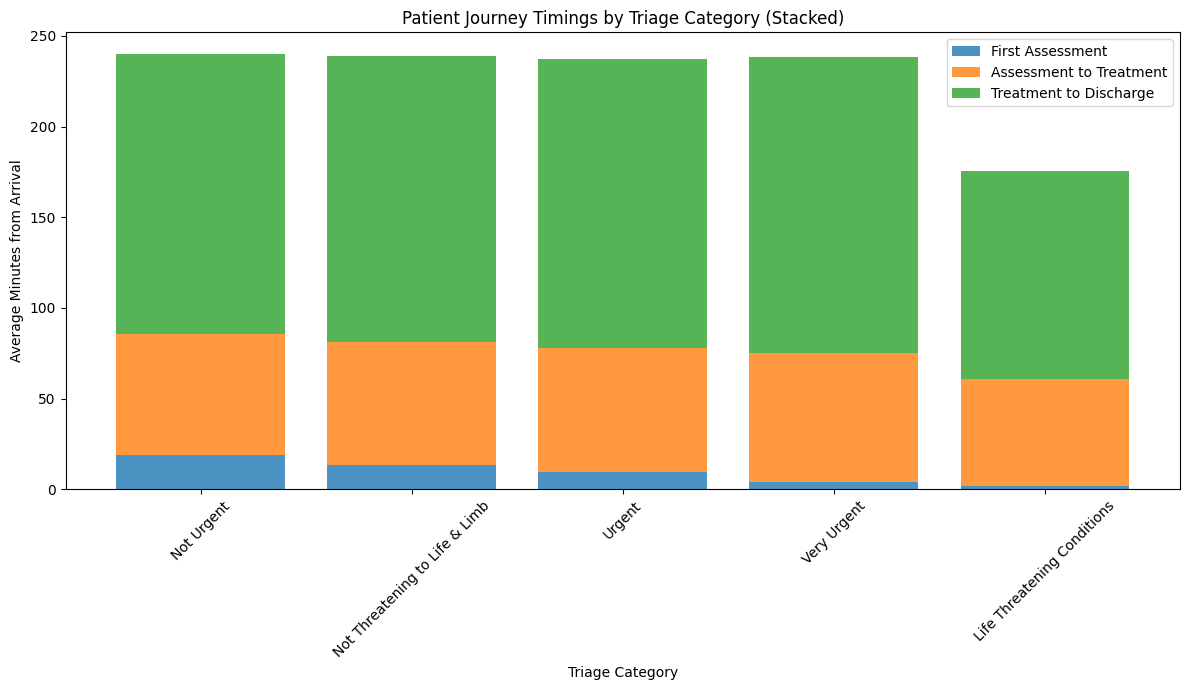

In [ ]:
plt.figure(figsize=(12, 7))
plt.bar(
    query_1_df['triage_name'],
    query_1_df['avg_mins_to_first_assessment'],
    label='First Assessment',
    color='blue',
    alpha=0.8
)
plt.bar(
    query_1_df['triage_name'],
    query_1_df['avg_mins_to_treatment_start'] - query_1_df['avg_mins_to_first_assessment'],
    bottom=query_1_df['avg_mins_to_first_assessment'],
    label='Assessment to Treatment',
    color='#ff7f0e',
    alpha=0.8
)
plt.bar(
    query_1_df['triage_name'],
    query_1_df['avg_total_visit_mins'] - query_1_df['avg_mins_to_treatment_start'],
    bottom=query_1_df['avg_mins_to_treatment_start'],
    label='Treatment to Discharge',
    color='#2ca02c',
    alpha=0.8
)
plt.title('Patient Journey Timings by Triage Category (Stacked)')
plt.xlabel('Triage Category')
plt.ylabel('Average Minutes from Arrival')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()